# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

In [1]:
#creating data frame

import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../../Mod04 Regression/Assignment/album_sales.csv")
df.head()

,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


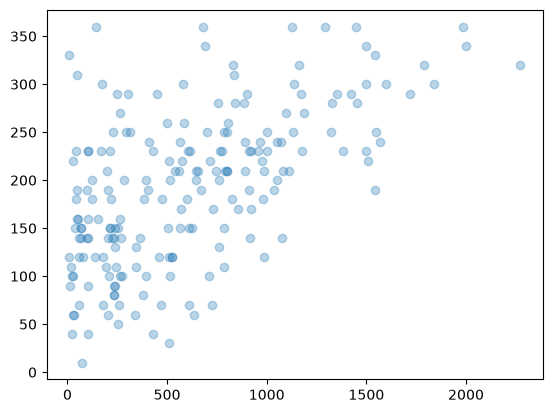

In [2]:
#sales and adverts
plt.scatter(x=df['adverts'], y = df['sales'], alpha=0.3)
plt.show()

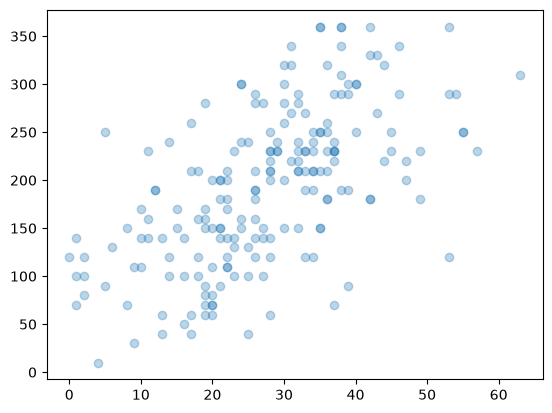

In [3]:
#sales and airplay
plt.scatter(x=df['airplay'], y = df['sales'], alpha=0.3)
plt.show()

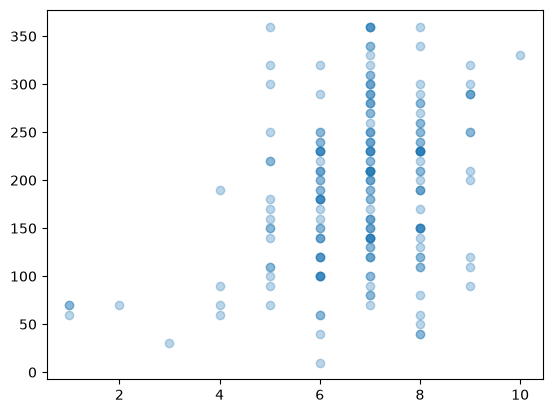

In [4]:
#sales and attract
plt.scatter(x=df['attract'], y = df['sales'], alpha=0.3)
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

For the sales and adverts, the scatterplot seems to show some positive correlation, but it seems to get weaker as the sales goes up.

For the sales and airplay, there definitely seems to be a moderate, positive correlation.

For the sales and attract, there seems to be a correlation, but since the x-axis is so confined I am unsure on how much of a relationship there is.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [5]:
# Code here
x = df['adverts']
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        23:13:32   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The p-value observed means that the data can not easily be replicated through randomness. That means that there is some sort of relationship to look at. The f-statistic observed says that there is a strong relationship to look at.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [6]:
# Code here
# The equation with the given parts of the regression line is now:
# Album Sales = 134.1399 + (0.0961 * Advert Budget)

x = 134.1399 + (0.0961 * 135000)
print(x)

13107.6399


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [7]:
# Code here
x = df[['adverts', 'airplay', 'attract']]
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        23:13:32   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

The second model, the multiple regression model, is better. Even though it has a p-value on the constant of 0.127, it has a much higher R^2 value which means it accounts for much more of the variance. Since we want a model that accounts for as much as possible, the second model is better.

### Submission to D2L Dropbox
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name

- Include the link to your GitHub repository (the URL of your repo page, for
   example `https://github.com/yourname/csci-4047-work`).
### How to add my code to GitHub?

1. Stage your file (this tells Git which changes to include):

      `git add Last_First_Assignment4.ipynb`

   To stage everything (you might not want to stage everything though) in the folder instead, use `git add .`

3. Commit your changes (this saves a snapshot with a message):

       git commit -m "Add Assignment 4"

   The text in quotes is your commit message. Make it describe what you
   did.

4. Push your commit up to GitHub:

       git push -u origin main

   The `-u origin main` part is only needed the first push. After that,
   `git push` alone is enough.

**What each command does, briefly**

- `git add` picks which files to include in the next save.
- `git commit` saves a snapshot of those files on your computer, with a
  message describing the change.
- `git push` uploads your saved commits to GitHub so they appear online.